In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer # Necesario para usar skl_imp, no borrar
from src.preprocessing import *

In [2]:
# Abrir archivo raw_data
data_folder = "data"
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17986 entries, 0 to 17985
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                17986 non-null  object 
 1   Close               17986 non-null  float64
 2   Ticker              17986 non-null  object 
 3   Monthly_Return      17514 non-null  float64
 4   Monthly_Variance    17514 non-null  float64
 5   Market_Covariance   17514 non-null  float64
 6   MarketCap           17935 non-null  float64
 7   EnterpriseValue     17935 non-null  float64
 8   PE_Trailing         17896 non-null  float64
 9   EnterpriseToEbitda  17935 non-null  float64
 10  PriceToBook         17896 non-null  float64
 11  operatingMargins    17986 non-null  float64
 12  profitMargins       17947 non-null  float64
 13  returnOnEquity      17908 non-null  float64
 14  ReturnOnAssets      17947 non-null  float64
 15  debtToEquity        17947 non-null  float64
 16  curr

In [3]:
columnas_a_eliminar = ['Close']
df.drop(columnas_a_eliminar, axis=1, inplace=True)

# Formatear market cap y EnterpriseValue en billions
df["MarketCap"] = df["MarketCap"] / 10**9
df["EnterpriseValue"] = df["EnterpriseValue"] / 10**9

# Variables continuas

In [4]:
# Distribucion de variables continuas
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Monthly_Return,17514.0,0.01,0.10,-0.52,-0.04,0.01,0.06,1.43
Monthly_Variance,17514.0,0.01,0.01,0.00,0.00,0.01,0.01,0.37
Market_Covariance,17514.0,0.00,0.00,-0.00,0.00,0.00,0.00,0.02
MarketCap,17935.0,108.02,348.80,0.70,18.21,35.04,76.74,5137.17
EnterpriseValue,17935.0,120.08,353.23,3.16,22.79,43.60,90.52,5137.61
PE_Trailing,17896.0,-15.34,1987.57,-101202.95,15.54,24.27,36.34,5658.65
EnterpriseToEbitda,17935.0,22.68,90.92,-1813.33,11.08,15.78,22.00,3204.70
PriceToBook,17896.0,6.88,52.68,-1113.18,1.87,3.74,8.08,1353.06
operatingMargins,17986.0,0.19,0.15,-1.60,0.11,0.18,0.26,0.93
profitMargins,17947.0,0.13,0.16,-1.72,0.07,0.12,0.20,1.04


In [5]:
# Coeficientes de asimetria
df.select_dtypes(include="number").skew()

Monthly_Return         1.521220
Monthly_Variance      11.980931
Market_Covariance      1.343333
MarketCap              8.258320
EnterpriseValue        8.120426
PE_Trailing          -39.313660
EnterpriseToEbitda    13.531623
PriceToBook            6.937696
operatingMargins      -0.439499
profitMargins         -1.904024
returnOnEquity         0.731541
ReturnOnAssets         0.714233
debtToEquity          -4.318166
currentRatio           6.739266
Revenue_Growth_YoY     3.571799
EBITDA_Growth_YoY    -11.833960
FEDFUNDS              -0.717116
GS10                  -0.710536
T10Y2Y                -0.234983
CPIAUCSL               0.036733
UNRATE                -0.341588
AAA                   -0.606540
DTWEXAFEGS             0.264771
dtype: float64

Cont


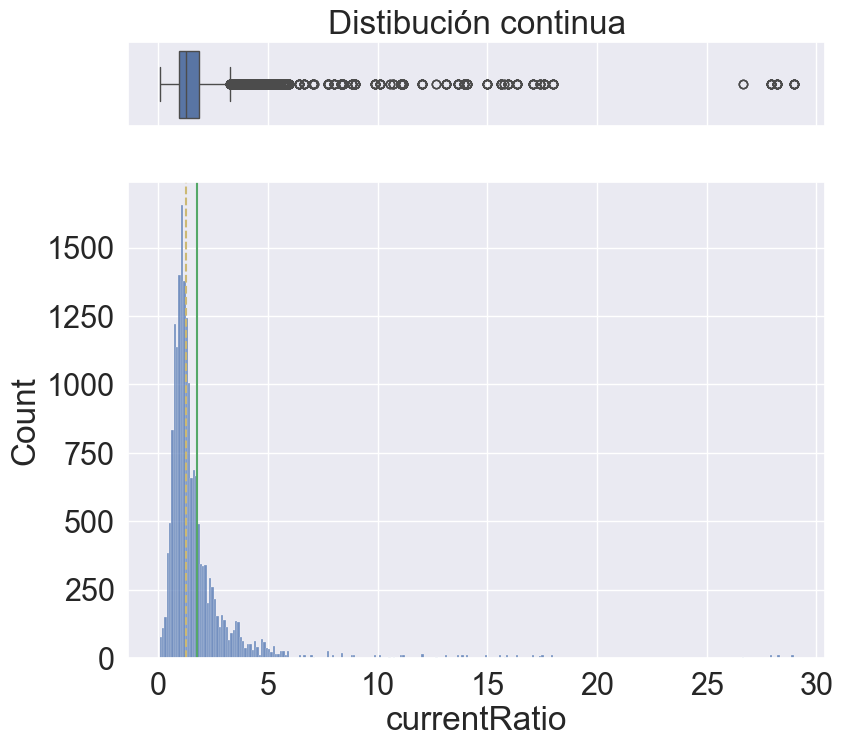

In [6]:
# Graficar
columna_a_graficar = 'currentRatio' # indicar columna para el grafico
plot(df[columna_a_graficar])

In [7]:
# Transformacion yeo-johnson
pt = PowerTransformer(method='yeo-johnson', standardize=True)
columnas_a_transformar = ['PriceToBook', 'returnOnEquity', 'PE_Trailing', 'EnterpriseToEbitda']
for columna in columnas_a_transformar:
    df[f'{columna}_Transformed'] = pt.fit_transform(df[[columna]])
    # Elimino la columna sin transformar
    df.drop(columna, axis=1, inplace=True)

In [8]:
# Transformaciones logarítmicas
columnas_a_transformar = ['MarketCap', 'EnterpriseValue', 'debtToEquity', 'currentRatio']
for columna in columnas_a_transformar:
    df[f'{columna}_log'] = np.log1p(df[columna])
    df.drop(columna, axis=1, inplace=True)

# Coeficientes de asimetria actualizado
df.select_dtypes(include="number").skew()

c:\Users\sebas\anaconda3\envs\ucm-dev\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Monthly_Return                     1.521220
Monthly_Variance                  11.980931
Market_Covariance                  1.343333
operatingMargins                  -0.439499
profitMargins                     -1.904024
ReturnOnAssets                     0.714233
Revenue_Growth_YoY                 3.571799
EBITDA_Growth_YoY                -11.833960
FEDFUNDS                          -0.717116
GS10                              -0.710536
T10Y2Y                            -0.234983
CPIAUCSL                           0.036733
UNRATE                            -0.341588
AAA                               -0.606540
DTWEXAFEGS                         0.264771
PriceToBook_Transformed            4.433324
returnOnEquity_Transformed        -0.141480
PE_Trailing_Transformed            9.938143
EnterpriseToEbitda_Transformed     9.444468
MarketCap_log                      1.140142
EnterpriseValue_log                1.089727
debtToEquity_log                   2.399541
currentRatio_log                

## Gestion de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [9]:
# Outliers
df_cont = df.select_dtypes(include="number")
df_winsor = df_cont.apply(lambda x: gestiona_outliers(x, clas='winsor'))

Monthly_Return
Monthly_Variance
Market_Covariance
operatingMargins
profitMargins
ReturnOnAssets
Revenue_Growth_YoY
EBITDA_Growth_YoY
FEDFUNDS
GS10
T10Y2Y
CPIAUCSL
UNRATE
AAA
DTWEXAFEGS
PriceToBook_Transformed
returnOnEquity_Transformed
PE_Trailing_Transformed
EnterpriseToEbitda_Transformed
MarketCap_log
EnterpriseValue_log
debtToEquity_log
currentRatio_log


In [10]:
# Coeficientes de asimetria actualizados luego de winsorizar
df_winsor.skew()

Monthly_Return                    0.453039
Monthly_Variance                  1.759442
Market_Covariance                 1.038091
operatingMargins                  0.528254
profitMargins                     0.152278
ReturnOnAssets                    0.579405
Revenue_Growth_YoY                0.208168
EBITDA_Growth_YoY                 0.454568
FEDFUNDS                         -0.717116
GS10                             -0.710536
T10Y2Y                           -0.234983
CPIAUCSL                          0.036733
UNRATE                           -0.341588
AAA                              -0.606540
DTWEXAFEGS                        0.264771
PriceToBook_Transformed           0.212380
returnOnEquity_Transformed        0.882806
PE_Trailing_Transformed           0.951622
EnterpriseToEbitda_Transformed    0.968428
MarketCap_log                     1.140142
EnterpriseValue_log               1.089727
debtToEquity_log                  1.492515
currentRatio_log                  1.267591
dtype: floa

Cont


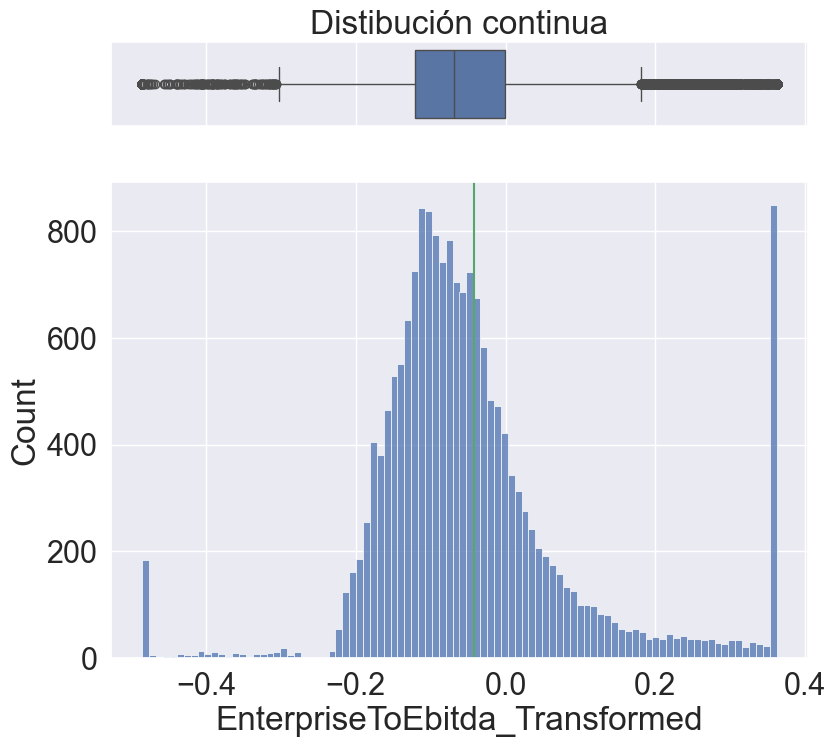

In [11]:
# Visualizar cambios
columna_a_graficar = 'EnterpriseToEbitda_Transformed' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [12]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Return,17514.0,0.013463,0.089984,-0.356837,-0.041419,0.010946,0.062688,0.375544
Monthly_Variance,17514.0,0.007812,0.006224,0.000622,0.003584,0.005857,0.009780,0.028417
Market_Covariance,17514.0,0.001638,0.001497,-0.003955,0.000618,0.001377,0.002409,0.007783
operatingMargins,17986.0,0.191854,0.140423,-0.359800,0.106500,0.177500,0.261300,0.741900
profitMargins,17947.0,0.136066,0.129918,-0.353200,0.067100,0.121300,0.197900,0.603100
ReturnOnAssets,17947.0,0.079396,0.077143,-0.227700,0.033000,0.063500,0.117400,0.388700
Revenue_Growth_YoY,12549.0,0.052409,0.127215,-0.328167,-0.002829,0.048265,0.105286,0.439850
EBITDA_Growth_YoY,12549.0,0.103123,0.355743,-0.852690,-0.048352,0.076013,0.214375,1.002882
FEDFUNDS,17983.0,4.651548,0.639034,1.210000,4.330000,4.640000,5.330000,5.330000
GS10,17983.0,4.162093,0.307409,2.900000,4.060000,4.210000,4.380000,4.800000


# Variables Categoricas

In [13]:
df_non_numeric = df.select_dtypes(exclude='number')

In [14]:
# Valores unicos
df_non_numeric.nunique()

Date            48
Ticker         454
Sector          11
SubIndustry    119
DateAdded      338
dtype: int64

In [15]:
# Convertir Sector y SubIndustrya category
df_non_numeric['Sector'] = df_non_numeric['Sector'].astype('category')
df_non_numeric['SubIndustry'] = df_non_numeric['SubIndustry'].astype('category')

# Valores unicos en Sector
df_non_numeric['Sector'].value_counts()

Sector
Industrials              3123
InformationTechnology    2828
HealthCare               2200
ConsumerDiscretionary    1900
ConsumerStaples          1477
Financials               1268
RealEstate               1209
Utilities                1174
Materials                1025
CommunicationServices     925
Energy                    857
Name: count, dtype: int64

In [16]:
# Valores unicos en SubIndustry
df_non_numeric['SubIndustry'].value_counts()

SubIndustry
HealthCareEquipment                        642
ElectricUtilities                          585
ApplicationSoftware                        570
Semiconductors                             562
IndustrialMachinery&Supplies&Components    556
                                          ... 
FoodRetail                                  38
HomefurnishingRetail                        38
Footwear                                    37
HeavyElectricalEquipment                    15
HealthCareTechnology                        15
Name: count, Length: 119, dtype: int64

In [17]:
df_non_numeric[df_non_numeric['Sector'].isnull()]

,Date,Ticker,Sector,SubIndustry,DateAdded


In [18]:
# Transformar DateAdded a datetime y convertir a YearsSinceAdded
df_non_numeric['DateAdded'] = pd.to_datetime(df_non_numeric['DateAdded'], errors='coerce')
df_non_numeric['YearsSinceAdded'] = round(((pd.Timestamp.now() - df_non_numeric['DateAdded']).dt.days / 365.25), 0)
df_non_numeric.drop('DateAdded', axis=1, inplace=True)

In [19]:
# Merge de variables continuas transformadas y variables no numericas
df_combined = pd.concat([df_non_numeric, df_winsor], axis=1)
df_combined.head()

,Date,Ticker,Sector,SubIndustry,YearsSinceAdded,Monthly_Return,Monthly_Variance,Market_Covariance,operatingMargins,profitMargins,...,AAA,DTWEXAFEGS,PriceToBook_Transformed,returnOnEquity_Transformed,PE_Trailing_Transformed,EnterpriseToEbitda_Transformed,MarketCap_log,EnterpriseValue_log,debtToEquity_log,currentRatio_log
0,2023-01-01,A,HealthCare,LifeSciencesTools&Services,26.0,NaN,NaN,NaN,0.2363,0.1831,...,4.90,118.4207,0.037637,0.013794,-0.038175,0.023661,3.814930,3.852051,0.420025,1.108596
1,2023-02-01,A,HealthCare,LifeSciencesTools&Services,26.0,NaN,NaN,NaN,0.2363,0.1831,...,4.43,115.6071,0.027140,0.013794,-0.044473,0.006620,3.747707,3.787359,0.420025,1.108596
2,2023-03-01,A,HealthCare,LifeSciencesTools&Services,26.0,NaN,NaN,NaN,0.2363,0.1831,...,4.40,113.8861,0.023370,0.013794,-0.046716,0.000497,3.722424,3.763071,0.420025,1.108596
3,2023-04-01,A,HealthCare,LifeSciencesTools&Services,26.0,-0.021035,0.005672,0.003620,0.2363,0.1831,...,4.56,116.7462,0.020345,0.013794,-0.048508,-0.004414,3.701684,3.743165,0.420025,1.108596
4,2023-05-01,A,HealthCare,LifeSciencesTools&Services,26.0,-0.144514,0.007249,0.003212,0.2363,0.1831,...,4.60,114.5737,-0.000012,0.013794,-0.060381,-0.037480,3.549758,3.597885,0.420025,1.108596


# Missings

In [20]:
df_combined.isnull().sum()

Date                                 0
Ticker                               0
Sector                               0
SubIndustry                          0
YearsSinceAdded                      0
Monthly_Return                     472
Monthly_Variance                   472
Market_Covariance                  472
operatingMargins                     0
profitMargins                       39
ReturnOnAssets                      39
Revenue_Growth_YoY                5437
EBITDA_Growth_YoY                 5437
FEDFUNDS                             3
GS10                                 3
T10Y2Y                               3
CPIAUCSL                           456
UNRATE                             456
AAA                                  3
DTWEXAFEGS                           3
PriceToBook_Transformed             90
returnOnEquity_Transformed          78
PE_Trailing_Transformed             90
EnterpriseToEbitda_Transformed      51
MarketCap_log                       51
EnterpriseValue_log      

In [21]:
# Resto de las continuas: imputar multivariable con IterativeImputer
df_cont = df_combined.select_dtypes(include='number')
# Imputador: Chain equations
imputer_itImp = skl_imp.IterativeImputer(max_iter=10, random_state=0)

In [22]:
df_imputed = pd.DataFrame(imputer_itImp.fit_transform(df_cont),columns=df_cont.columns)
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17986 entries, 0 to 17985
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   YearsSinceAdded                 17986 non-null  float64
 1   Monthly_Return                  17986 non-null  float64
 2   Monthly_Variance                17986 non-null  float64
 3   Market_Covariance               17986 non-null  float64
 4   operatingMargins                17986 non-null  float64
 5   profitMargins                   17986 non-null  float64
 6   ReturnOnAssets                  17986 non-null  float64
 7   Revenue_Growth_YoY              17986 non-null  float64
 8   EBITDA_Growth_YoY               17986 non-null  float64
 9   FEDFUNDS                        17986 non-null  float64
 10  GS10                            17986 non-null  float64
 11  T10Y2Y                          17986 non-null  float64
 12  CPIAUCSL                        

In [23]:
df_final = pd.concat([df_imputed, df_combined.select_dtypes(exclude='number')], axis=1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17986 entries, 0 to 17985
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   YearsSinceAdded                 17986 non-null  float64 
 1   Monthly_Return                  17986 non-null  float64 
 2   Monthly_Variance                17986 non-null  float64 
 3   Market_Covariance               17986 non-null  float64 
 4   operatingMargins                17986 non-null  float64 
 5   profitMargins                   17986 non-null  float64 
 6   ReturnOnAssets                  17986 non-null  float64 
 7   Revenue_Growth_YoY              17986 non-null  float64 
 8   EBITDA_Growth_YoY               17986 non-null  float64 
 9   FEDFUNDS                        17986 non-null  float64 
 10  GS10                            17986 non-null  float64 
 11  T10Y2Y                          17986 non-null  float64 
 12  CPIAUCSL          

In [24]:
df_final.select_dtypes(include='number').skew()

YearsSinceAdded                   1.035121
Monthly_Return                    0.480540
Monthly_Variance                  1.733591
Market_Covariance                 0.962806
operatingMargins                  0.528254
profitMargins                     0.148038
ReturnOnAssets                    0.574318
Revenue_Growth_YoY                0.179184
EBITDA_Growth_YoY                 0.537310
FEDFUNDS                         -0.717170
GS10                             -0.710594
T10Y2Y                           -0.235000
CPIAUCSL                         -0.011985
UNRATE                           -0.385398
AAA                              -0.606589
DTWEXAFEGS                        0.264789
PriceToBook_Transformed           0.209086
returnOnEquity_Transformed        0.886058
PE_Trailing_Transformed           0.946740
EnterpriseToEbitda_Transformed    0.972366
MarketCap_log                     1.143558
EnterpriseValue_log               1.091425
debtToEquity_log                  0.034214
currentRati

In [25]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")